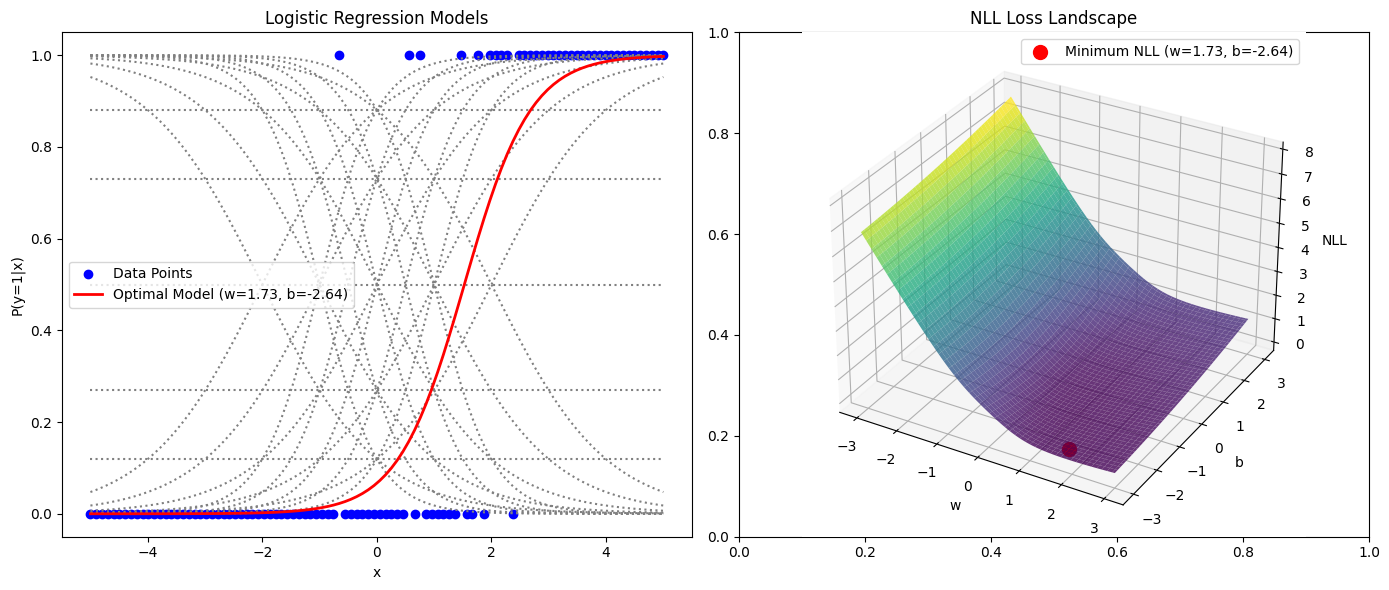

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate a more complex dataset with a non-trivial decision boundary
np.random.seed(0)
x_values = np.linspace(-5, 5, 100)
# Non-trivial decision boundary with some noise
y_values = (x_values + np.random.normal(scale=1.5, size=x_values.shape) > 1).astype(int)

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Calculate probability for a given w, b
def probability(x, w, b):
    return sigmoid(w * x + b)

# Define a range of possible w and b values for plotting the NLL landscape
w_values = np.linspace(-3, 3, 100)
b_values = np.linspace(-3, 3, 100)

# Meshgrid for the loss landscape
W, B = np.meshgrid(w_values, b_values)

# Calculate the NLL for each pair of w, b values
NLL = np.zeros(W.shape)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        z = W[i, j] * x_values + B[i, j]
        probs = sigmoid(z)
        NLL[i, j] = -np.mean(y_values * np.log(probs) + (1 - y_values) * np.log(1 - probs))

# Find the minimum NLL and corresponding w, b
min_idx = np.unravel_index(np.argmin(NLL, axis=None), NLL.shape)
optimal_w = W[min_idx]
optimal_b = B[min_idx]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Several logistic regression models
axes[0].scatter(x_values, y_values, color='blue', label='Data Points')
for w in np.linspace(-2, 2, 5):
    for b in np.linspace(-2, 2, 5):
        axes[0].plot(x_values, probability(x_values, w, b), linestyle=':', color='gray')
axes[0].plot(x_values, probability(x_values, optimal_w, optimal_b), color='red', label=f'Optimal Model (w={optimal_w:.2f}, b={optimal_b:.2f})', linewidth=2)
axes[0].set_title("Logistic Regression Models")
axes[0].set_xlabel('x')
axes[0].set_ylabel('P(y=1|x)')
axes[0].legend()

# Right Plot: NLL loss landscape
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(W, B, NLL, cmap='viridis', alpha=0.8)
ax2.scatter(optimal_w, optimal_b, np.min(NLL), color='red', s=100, label=f'Minimum NLL (w={optimal_w:.2f}, b={optimal_b:.2f})')
ax2.set_title("NLL Loss Landscape")
ax2.set_xlabel('w')
ax2.set_ylabel('b')
ax2.set_zlabel('NLL')
ax2.legend()

plt.tight_layout()
plt.show()


## Interactive Controls\nUse the widget panel below to explore parameters live inside JupyterLite.\n

In [ ]:
# INTERACTIVE_WIDGET_SECTION\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport ipywidgets as widgets\n\nrng = np.random.default_rng(2)\nx = np.linspace(-4,4,120)\ny = (x + 0.8*rng.normal(size=x.size) > 0).astype(float)\n\ndef _sig(z):\n    return 1/(1+np.exp(-z))\n\ndef _plot_nll(w=1.0, b=0.0):\n    p = _sig(w*x + b)\n    nll = -(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9)).mean()\n    plt.figure(figsize=(8,5))\n    plt.scatter(x, y, s=10, alpha=0.6, label='data')\n    plt.plot(x, p, lw=2, label=f'p(y=1|x), NLL={nll:.3f}')\n    plt.ylim(-0.1,1.1)\n    plt.grid(True)\n    plt.legend()\n    plt.title('Interactive Logistic/NLL')\n    plt.show()\n\nwidgets.interact(_plot_nll,\n    w=widgets.FloatSlider(value=1.0, min=-5, max=5, step=0.1),\n    b=widgets.FloatSlider(value=0.0, min=-5, max=5, step=0.1))\n